# Bootstrapping Uncertainty Visualization

This notebook visualizes uncertainty images generated by the bootstrapping method for the 'lung' dataset across different intensities and angles.

Note: We use specific schedule points [11, 91, 180] corresponding to angles 10, 90, and ~180 degrees. Using N > 1 is crucial for bootstrapping availability.

In [5]:
import uqct 

import torch
import matplotlib.pyplot as plt
from uqct.other_methods.bootstrapping import get_bootstrap_predictor
from uqct.eval.run import setup_experiment
from uqct.ct import circular_mask
import numpy as np

%matplotlib inline

In [2]:
def get_uncertainty_images(total_intensity, dataset='lung', n_bootstraps=20):
    # Configuration
    # Angles 10, 90, 180.
    n_angles = 180
    max_angle = 180
    schedule_length = 180
    schedule_start = 1
    
    # We want indices that correspond to including angles up to 10, 90, 180.
    # Angle 0 is index 0.
    # Angle 10 is index 10. To include it, we need 11 angles (0..10).
    # Angle 90 is index 90. Need 91 angles.
    # Angle 179 is index 179. Need 180 angles.
    
    schedule_labels = torch.tensor([10, 90, 180])
    
    # Setup Experiment
    image_range = (0, 1)
    seed = 42
    sparse = True
    
    gt, experiment, _ = setup_experiment(
        dataset,
        image_range,
        total_intensity,
        sparse,
        seed,
        schedule_length,
        schedule_start,
        'all',
        n_angles,
        max_angle
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    experiment = experiment.to(device)
    
    # Get Predictor
    # We use comparison=True to get [min, max] directly
    predictor = get_bootstrap_predictor(n_bootstraps, comparison=True, minmax=True)
    
    print(f"Processing Intensity {total_intensity}...")
    
    # Run Predictor
    # Returns (N, T, 2, H, W)
    with torch.no_grad():
        preds = predictor(experiment, schedule_labels)
    
    uncertainties = []
    
    # Iterate over T (schedule steps)
    for t in range(preds.shape[1]):
        # preds[0, t, 0] is min, preds[0, t, 1] is max
        min_val = preds[0, t, 0]
        max_val = preds[0, t, 1]
        
        uncertainty = (max_val - min_val).cpu().numpy()
        uncertainties.append(uncertainty)
        
    return uncertainties, schedule_labels

Experiment: Experiment(sparse=True, intensities=tensor[1, 180, 1] x∈[0.434, 0.434] μ=0.434 σ=0. cuda:0, counts=tensor[1, 180, 128] n=23040 (90Kb) x∈[0., 5.000] μ=0.249 σ=0.502 cuda:0, angles=tensor[180] f64 1.4Kb x∈[0., 179.000] μ=89.500 σ=52.106 cuda:0)
Processing Intensity 10000.0...
Experiment: Experiment(sparse=True, intensities=tensor[1, 180, 1] x∈[43.403, 43.403] μ=43.403 σ=0. cuda:0, counts=tensor[1, 180, 128] n=23040 (90Kb) x∈[5.000, 70.000] μ=24.916 σ=7.934 cuda:0, angles=tensor[180] f64 1.4Kb x∈[0., 179.000] μ=89.500 σ=52.106 cuda:0)
Processing Intensity 1000000.0...
Experiment: Experiment(sparse=True, intensities=tensor[1, 180, 1] x∈[4.340e+04, 4.340e+04] μ=4.340e+04 σ=0. cuda:0, counts=tensor[1, 180, 128] n=23040 (90Kb) x∈[1.384e+04, 4.383e+04] μ=2.485e+04 σ=6.206e+03 cuda:0, angles=tensor[180] f64 1.4Kb x∈[0., 179.000] μ=89.500 σ=52.106 cuda:0)
Processing Intensity 1000000000.0...


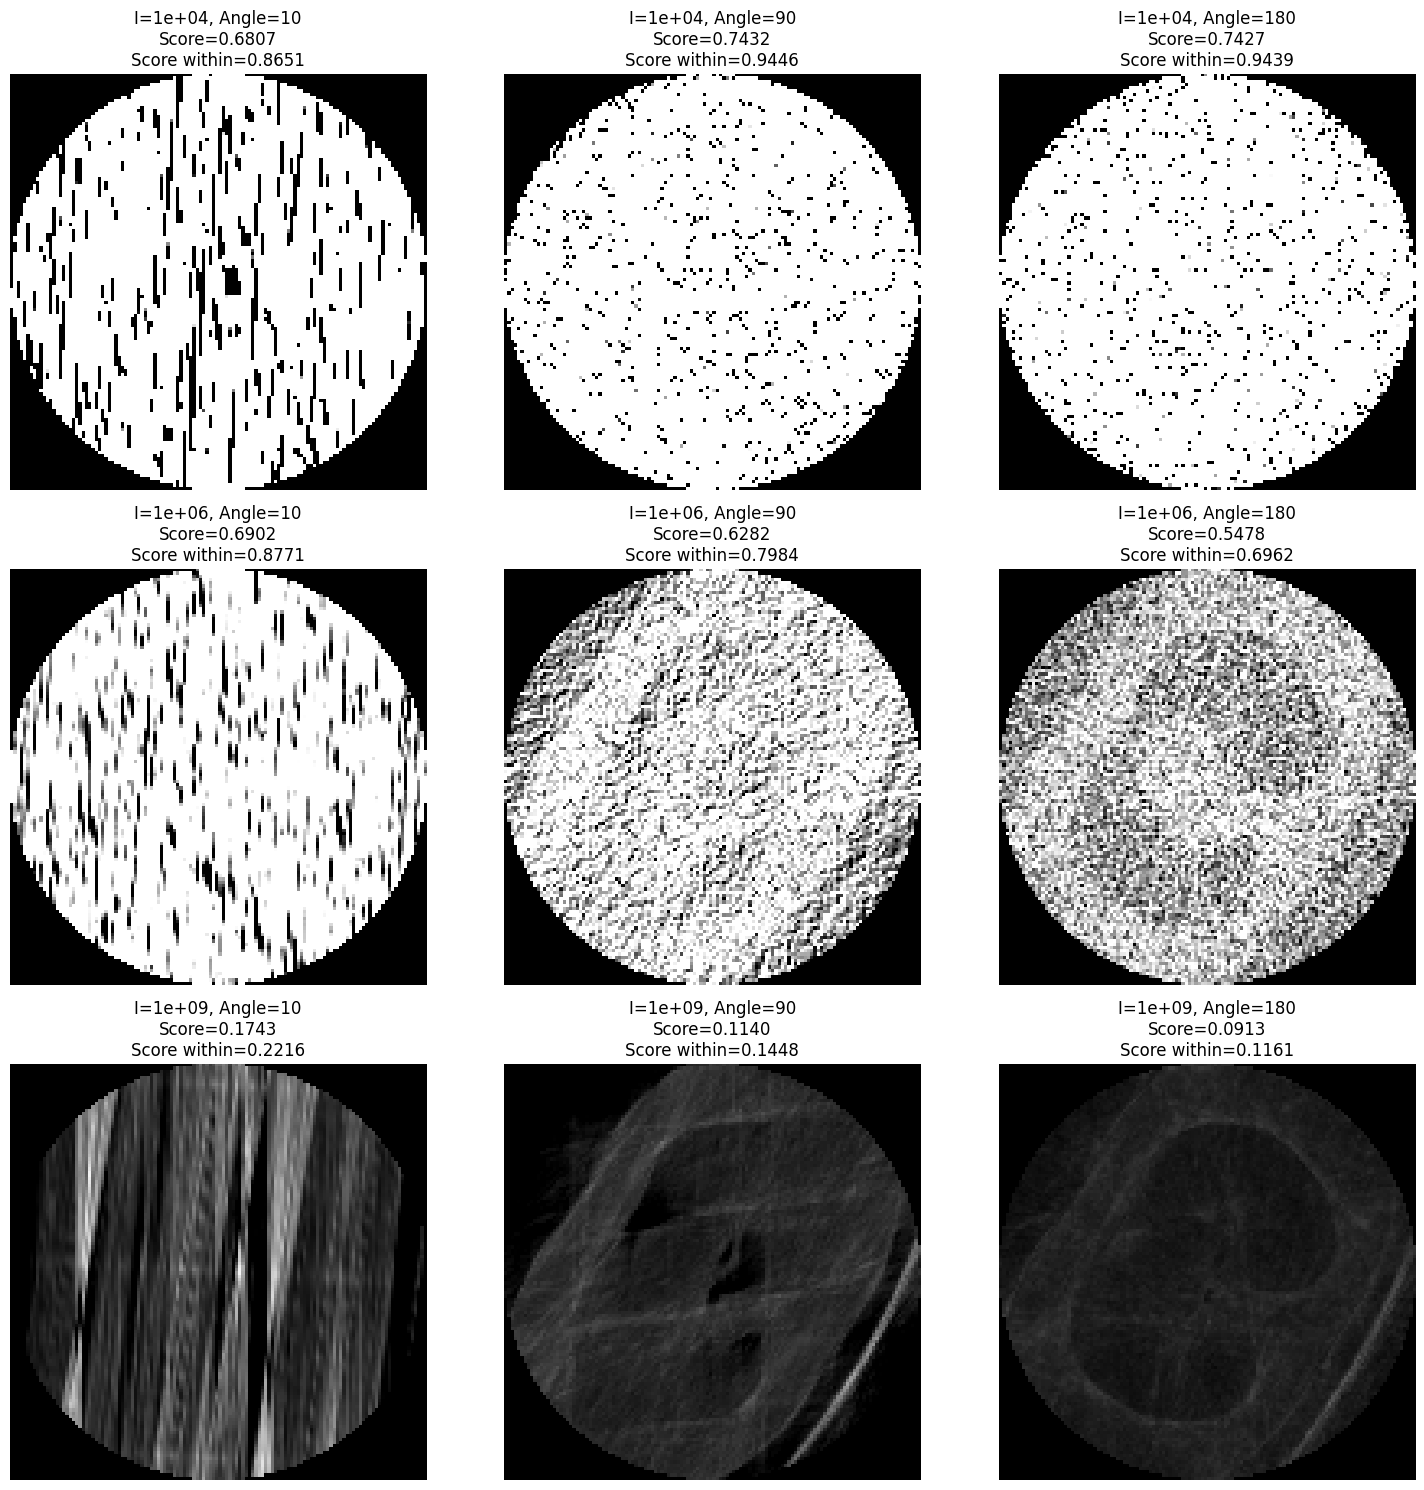

In [7]:
intensities = [1e4, 1e6, 1e9]

fig, axes = plt.subplots(len(intensities), 3, figsize=(15, 5*len(intensities)))

for i, intensity in enumerate(intensities):
    uncs, angles = get_uncertainty_images(intensity, dataset='lung', n_bootstraps=50)
    
    for j, (unc, angle) in enumerate(zip(uncs, angles)):
        ax = axes[i, j]
        im = ax.imshow(unc, cmap='gray', vmin=0, vmax=1)
        score = unc.mean()
        score_within = unc[..., circular_mask(unc.shape[-1], dtype=bool)].mean()
        ax.set_title(f"I={intensity:.0e}, Angle={angle}\nScore={score:.4f}\nScore within={score_within:.4f}")
        ax.axis('off')

plt.tight_layout()
plt.show()